In [2]:
import pandas as pd 
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [3]:
fpath = 'data/meteor_opto_silencing_body_part_final.xlsx'

xls = pd.ExcelFile(fpath)
sheets = xls.sheet_names   # ['retinal (-)', 'retinal (+)']

data_df = {}
for s in sheets:
    df = pd.read_excel(fpath, sheet_name=s)
    data_df[s] = df

# body part condition 이름
conds = data_df[sheets[0]].columns

mean_df = pd.DataFrame(index=conds, columns=sheets)
err_df = pd.DataFrame(index=conds, columns=sheets)

for s, df in data_df.items():
    mean_df[s] = df.mean(axis=0, skipna=True)
    err_df[s] = df.apply(lambda x: x.dropna().sem(), axis=0)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

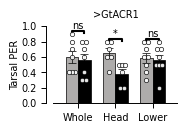

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(1.6, 1))

conds = [
    'SS35420>GtACR1 whole body',
    'SS35420>GtACR1 head',
    'SS35420>GtACR1 lower body'
]

groups = ['retinal -', 'retinal +']

ax, stat_all = draw_paired_bar_figure(
    data=data_df,
    mean_df=mean_df,
    err_df=err_df,
    bar_width=0.1,
    bar_spacing=.3,
    stat_fontsize=7,
    fontsize=7,
    dot_size=10,
    linewidth=.5,
    ax=ax,
    conds=conds,
    groups=groups,
    get_values=lambda data, cond, group: data[group][cond].dropna().values,
    stat_pairs=[
        ((conds[0], 'retinal -'), (conds[0], 'retinal +')),
        ((conds[1], 'retinal -'), (conds[1], 'retinal +')),
        ((conds[2], 'retinal -'), (conds[2], 'retinal +')),
    ],
    colors=['#AEACAB', 'black'],
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.replace('SS35420>GtACR1 ', ''),
    ylim=(0, 1),
    yticks=np.round(np.arange(0, 1.1, .2), 2)
)


# xlabel = ['SS35420\nwhole body', 'SS35420\nhead', 'SS35420\nlower body']
xlabel = ['Whole','Head','Lower']
bar_spacing = .3
num_bars = len(conds)
x_loc = np.arange(0, num_bars * bar_spacing, bar_spacing)

ax.set_xticks(x_loc)
ax.set_xticklabels(xlabel, fontsize=7, rotation=0)

ax.set_yticks(np.arange(0, 1.1, .2))
ax.set_yticklabels(np.round(np.arange(0, 1.1, .2), 2), fontsize=7)

ax.set_ylabel('Tarsal PER', fontsize=7, labelpad=1)
ax.set_ylim([0, 1])
ax.set_xlim(-0.2, (num_bars - 1) * bar_spacing + 0.2)

ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_position(('outward', 5))

ax.set_title('>GtACR1', fontsize=7)
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    
# plt.savefig('figures/meteor_silencing_each_body_part.svg')

In [7]:
stat_all

[(28.5, 0.3242633847615347),
 (32.5, 0.01148836331833278),
 (34.5, 0.41545894707177977)]